
# Note Detection 
Sophie Lin

(uses Alexandre R.J. Francois' Chroma and Chromagrams)


In [2]:
import sys
print(sys.executable)

/Users/sophielin/miniforge3/envs/noFFT_env/bin/python


In [3]:
import os
import time
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine, euclidean

from noFFT_utils import log_frequencies, alphas_heuristic, resonate_wrapper


# Pipeline

In [14]:
#------------Constants------------

#  128-bin filterbank
n_bins = 128
bins_per_octave = 12
fmin = 32.7 #lowest C 
hop_length = 1

(841728, 128)


/Users/sophielin/miniforge3/envs/noFFT_env/lib/python3.12/site-packages/scipy/spatial/distance.py:682: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


time: 4.879262924194336


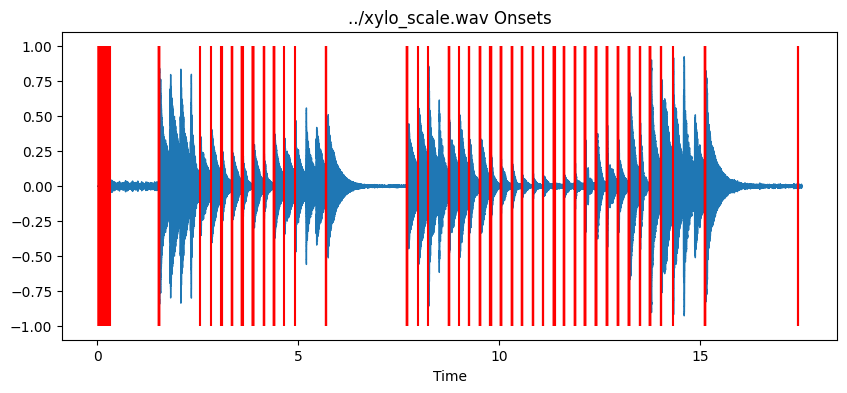

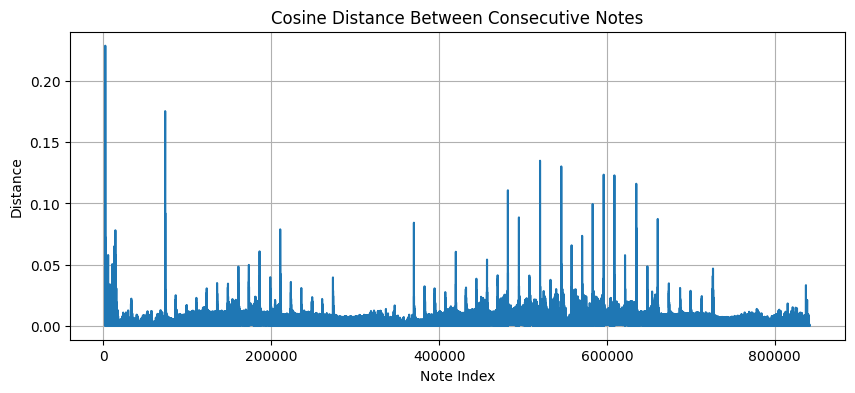

In [15]:
#------------Pipeline------------
folderpath = "../xylo_scale.wav"
file = os.path.join(folderpath)

start_time = time.time()

# Load audio
y, sr = librosa.load(file, sr=None)
frequencies = log_frequencies(fmin=fmin, n_freqs=n_bins,freqs_per_octave=bins_per_octave)
alphas = alphas_heuristic( frequencies, sr)

# resonator filterbank
R = resonate_wrapper(y, sr, frequencies, alphas)
print(R.shape) # R shape should be (time_frames, 128,)

#cosine similarity
cos_diff = []
for i in range(len(R) - 1):
    segment = R[i:i+1, :] 
    note_vector = cosine(R[i], R[i+1])
    #print(note_vector.shape)
    #print(note_vector)
    cos_diff.append(note_vector)
#print(f"cosine similarity length :({len(cos_diff)})")


#threshold for onsets
note_vectors = np.array(cos_diff)
onset_idx = np.where(note_vectors > 0.03)[0] #ids of onsets in frames

#change from frames to time
onset_times = onset_idx * hop_length / sr #convert to time 
onset_samples = (onset_times * sr).astype(int)

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.vlines(onset_times, -1, 1, color='r')
plt.title(f"{folderpath} Onsets")
#print(note_vectors)
#print(distance_cosine)


plt.figure(figsize=(10,4))
plt.plot(note_vectors, linestyle='-')
plt.title("Cosine Distance Between Consecutive Notes")
plt.ylabel("Distance")
plt.xlabel("Note Index")
plt.grid(True)

#time
end_time = time.time()
print(f"time: {end_time - start_time}")


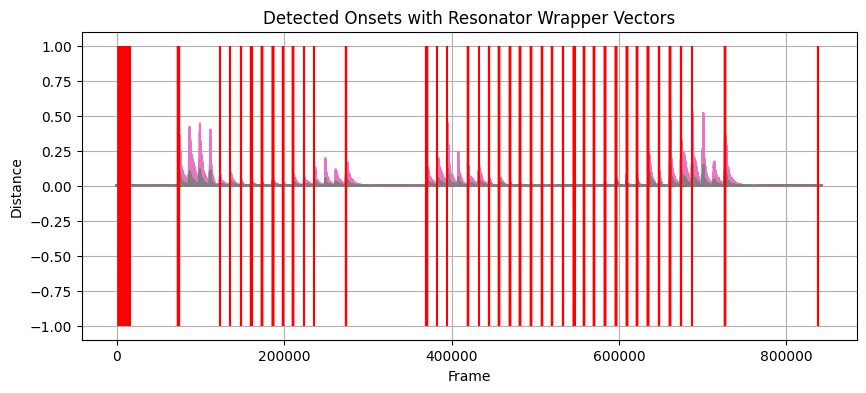

In [16]:
#plotting based on R
plt.figure(figsize=(10,4))
plt.plot(R, linestyle='-')
plt.vlines(onset_idx, -1, 1, color='r')
plt.title("Detected Onsets with Resonator Wrapper Vectors")
plt.ylabel("Distance")
plt.xlabel("Frame")
plt.grid(True)


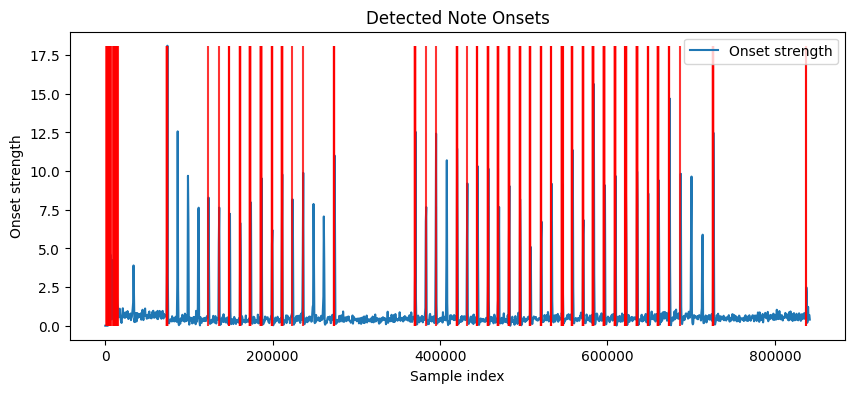

In [17]:
#gets onset strengths
onsets = librosa.onset.onset_strength(y=y, sr=sr)

#get the frames of where the strongest onsets are 
gt_onset_frames = librosa.onset.onset_detect(onset_envelope=onsets, sr=sr)
gt_onset_samples = librosa.frames_to_samples(gt_onset_frames) #changes frames to samples (since x-axis in samples)

#print(onset_frames)
#print(onset_samples)

#plot
plt.figure(figsize=(10, 4))
plt.plot(librosa.frames_to_samples(np.arange(len(onsets))), onsets, label='Onset strength')
peaks = onsets[onsets>5]
plt.vlines(onset_samples, 0, max(onsets), color='r', alpha=0.8)
plt.xlabel('Sample index')
plt.ylabel('Onset strength')
plt.title('Detected Note Onsets')
plt.legend()

In [18]:
score = 0
for gt in gt_onset_samples:
    if int(gt) in onset_samples:
        score+=1

print(f"accurcy: {score}/{len(gt_onset_samples)}")

accurcy: 0/51


In [19]:
#ground truth with totlerance (instead of exact frame)
tolerance = int(0.01 * sr) #10 ms -> turned into samples

matches = []
for gt in gt_onset_samples:
    if np.any(np.abs(onset_samples - gt) <= tolerance):
        matches.append(gt)

score = len(matches)
print(f"accurcy: {score}/{len(gt_onset_samples)}")

accurcy: 36/51


In [20]:

print(onset_samples)

[  2140   2141   2164   2165   2166   2185   2200   2221   2222   2223
   2238   2239   2255   2256   2257   2258   2268   2287   2288   2296
   2330   2331   2338   2371   2381   2432   2433   2608   2661   2662
   2767   2768   5318   5459   5519   5533   5534   5535   5996   6004
   6263   6264   8617  10537  10538  10577  10578  10735  10793  11664
  11886  12589  12594  12735  12735  12871  12872  12946  12950  13195
  13226  13341  13544  13544  13612  13613  13993  13993  14048  14152
  14152  14191  14192  14279  15293  73529  73530  73531  73532  73553
  73554  73555  73584  73619  73620  73639  73640 123040 135380 148241
 148380 148381 160707 160769 160770 160793 160816 160817 160839 160862
 173167 173183 173200 173236 173257 173277 173298 173321 173341 173360
 173400 173441 186004 186005 186006 186010 186028 186029 186030 186042
 186043 186057 186078 186100 186101 186124 186145 186146 186169 198762
 198786 198809 198810 198832 198855 198930 210604 210605 210626 210638
 21063

In [21]:
print(gt_onset_samples)

[  6144   8704  11264  33792  73728  86016  98816 111104 123392 135680
 148480 161280 173568 186368 199168 210944 223744 236032 248832 261120
 273920 370176 382976 394752 407552 420352 432128 444928 457216 470016
 482304 495616 507904 520704 533504 546304 558592 570880 583680 596480
 609280 622080 635392 648704 660992 674304 687104 699904 713216 726528
 837632]


# BabySlakh Dataset

In [4]:
#------------Constants------------

#  128-bin filterbank
n_bins = 128
bins_per_octave = 12
fmin = 32.7 #lowest C 
hop_length = 1
threshold = 0.04

In [ ]:
##------------Pipeline------------
folderpath = "../babyslakh_16k/Track00020/stems/S04.wav"
file = os.path.join(folderpath)
track_name = folderpath.split('/')[2]

start_time = time.time()

# Load audio
load_time = time.time()
print(f"loading audio: {load_time-start_time}")
y, sr = librosa.load(file, sr=None)
frequencies = log_frequencies(fmin=fmin, n_freqs=n_bins,freqs_per_octave=bins_per_octave)
alphas = alphas_heuristic( frequencies, sr)

# resonator filterbank
res_time = time.time()
print(f"resonate wrapper: {res_time-load_time}")
R = resonate_wrapper(y, sr, frequencies, alphas)
#print(R.shape) # R shape should be (time_frames, 128,)

#cosine similarity
cur_time = time.time()
print(f"taking euclidean diff: {cur_time-res_time}")
cos_diff = [euclidean(R[i],  R[i+1]) for i in range(len(R) - 1)]

#threshold for onsets
on_time = time.time()
print(f"detecting onsets: {on_time-cur_time}")
note_vectors = np.array(cos_diff)
onset_idx = np.where(note_vectors > threshold)[0] #ids of onsets in frames

#change from frames to time
fr_to_time_time = time.time()
print(f"detecting onsets: {fr_to_time_time-on_time}")
onset_times = onset_idx * hop_length / sr #convert to time 
onset_samples = (onset_times * sr).astype(int)

#plot
plot_time = time.time()
print(f"plotting: {plot_time-fr_to_time_time}")
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.vlines(onset_times, -1, 1, color='r')
plt.title(f"Predicted {track_name} Onsets with {threshold} threshold")
#print(note_vectors)
#print(distance_cosine)


plt.figure(figsize=(10,4))
plt.plot(note_vectors, linestyle='-')
plt.title("euclidian Distance Between Consecutive Notes")
plt.ylabel("Distance")
plt.xlabel("Note Index")
plt.grid(True)

#time
end_time = time.time()
print(f"time: {end_time - start_time}")


loading audio: 1.3113021850585938e-05
resonate wrapper: 0.9952900409698486
[resonate_wrapper] resonate: 2.03464412689209
n_freqs: 128
[resonate_wrapper] rsc np array: 12.008858680725098
[resonate_wrapper] reshape Rsc: 0.0009033679962158203
(5564059, 128) (5564059, 128)
[resonate_wrapper] compute complex values: 0.01478886604309082
taking euclidean diff: 14.30785584449768
detecting onsets: 18.10626792907715
detecting onsets: 0.11673712730407715
plotting: 0.0022230148315429688
time: 35.01170825958252


In [211]:
#check with midi file
%pip install mido
import mido

python(97959) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [212]:
mid_path = "../babyslakh_16k/Track00020/MIDI/S04.mid"
mid = mido.MidiFile(mid_path)

current_time = 0
events = []

for msg in mid:
    current_time += msg.time

    if msg.type == 'note_on' and msg.velocity > 0:
        events.append({
            "note": msg.note,
            "time": current_time,
            "velocity": msg.velocity
        })

dtype = [('note', int), ('time', float), ('velocity', int)]
events_arr = np.zeros(len(events), dtype=dtype)

events_arr['note'] = [e['note'] for e in events]
events_arr['time'] = [e['time'] for e in events]
events_time = np.unique(events_arr['time'])
events_arr['velocity'] = [e['velocity'] for e in events]

print(events_arr, len(events_time))

[(62,   5.03333333,  91) (66,   5.03333333,  91) (69,   5.03333333,  87)
 (62,   7.05      ,  91) (66,   7.05      ,  91) (69,   7.05      ,  84)
 (62,   9.06666667,  91) (66,   9.06666667,  91) (69,   9.06666667,  91)
 (62,  11.08333333,  87) (66,  11.08333333,  87) (69,  11.08333333,  91)
 (62,  13.1       ,  95) (67,  13.1       ,  91) (71,  13.1       ,  82)
 (62,  15.11666667,  87) (67,  15.11666667,  91) (71,  15.11666667,  76)
 (62,  17.13333333,  84) (66,  17.13333333,  99) (69,  17.13333333,  84)
 (62,  19.15      ,  95) (66,  19.15      ,  95) (69,  19.15      ,  87)
 (63,  21.16666667,  95) (66,  21.16666667,  91) (69,  21.16666667,  79)
 (71,  21.16666667,  73) (63,  23.18333333,  87) (66,  23.18333333,  82)
 (69,  23.18333333,  82) (71,  23.18333333,  82) (64,  25.2       ,  91)
 (67,  25.2       ,  91) (71,  25.2       ,  82) (64,  27.21666667,  84)
 (67,  27.21666667,  87) (71,  27.21666667,  82) (61,  29.23333333,  95)
 (64,  29.23333333,  87) (69,  29.23333333,  91) (6

In [213]:
print(len(onset_times))
onset_times

96394


array([  5.1238125,   5.1371875,   5.13725  , ..., 339.939375 ,
       339.9495   , 340.033375 ], shape=(96394,))

In [214]:
def quantize_time(arr):
    seen = set()
    result = []

    for t in arr:
        bucket = int(t // 0.01)
        if bucket not in seen:
            seen.add(bucket)
            result.append(bucket*0.01+ 0.005) #append middle of bucket

    return result
print(events_time)
print(quantize_time(events_time))

[  5.03333333   7.05         9.06666667  11.08333333  13.1
  15.11666667  17.13333333  19.15        21.16666667  23.18333333
  25.2         27.21666667  29.23333333  31.25        33.26666667
  34.26666667  41.33333333  43.35        45.36666667  47.38333333
  49.4         51.4         53.41666667  55.43333333  57.45
  59.46666667  61.48333333  63.5         65.51666667  66.53333333
  73.58333333  75.6         77.61666667  79.63333333  81.65
  83.66666667  85.68333333  87.7         89.71666667  91.73333333
  93.75        95.76666667  97.78333333  99.8        101.13333333
 101.46666667 101.8        102.48333333 102.81666667 105.16666667
 105.5        105.83333333 107.51666667 107.85       108.53333333
 109.53333333 109.86666667 110.55       111.88333333 112.21666667
 112.56666667 113.56666667 113.9        114.23333333 114.58333333
 114.91666667 115.58333333 115.91666667 116.6        117.26666667
 117.6        117.93333333 118.6        118.95       121.63333333
 121.96666667 122.3        12

In [215]:
#ground truth with totlerance (instead of exact frame)
tolerance = 0.01
events_time_quantized = quantize_time(events_time)

matches_babyslakh = []
for gt in events_time_quantized:

    # compute diff
    diff = onset_times - gt

    if np.any(np.abs(diff) <= tolerance):
        matches_babyslakh.append(gt)

score = len(matches_babyslakh)
print(f"accuracy: {score}/{len(events_time_quantized)}")

accuracy: 49/262


plotting: 0.002833127975463867


Text(0.5, 1.0, 'Ground truth Track00020')

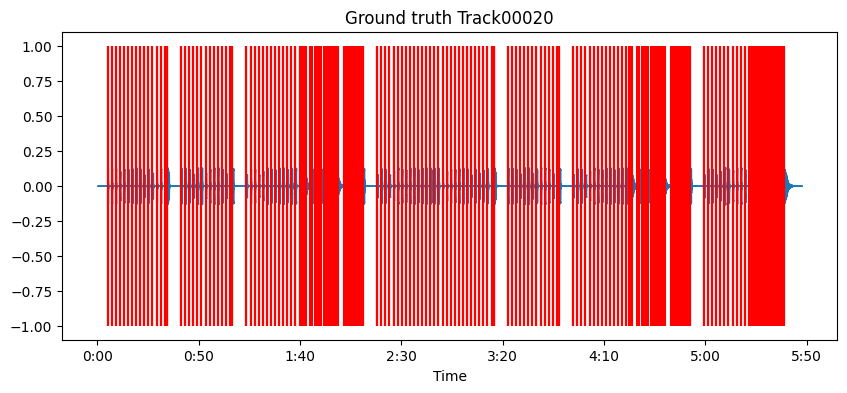

In [216]:
midi_times = np.array([events_arr['time'] for events_arr in events])

print(f"plotting: {plot_time-fr_to_time_time}")
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.vlines(midi_times, -1, 1, color='r')
plt.title(f"Ground truth {track_name}")

In [217]:
print(midi_times)

[  5.03333333   5.03333333   5.03333333   7.05         7.05
   7.05         9.06666667   9.06666667   9.06666667  11.08333333
  11.08333333  11.08333333  13.1         13.1         13.1
  15.11666667  15.11666667  15.11666667  17.13333333  17.13333333
  17.13333333  19.15        19.15        19.15        21.16666667
  21.16666667  21.16666667  21.16666667  23.18333333  23.18333333
  23.18333333  23.18333333  25.2         25.2         25.2
  27.21666667  27.21666667  27.21666667  29.23333333  29.23333333
  29.23333333  31.25        31.25        31.25        33.26666667
  33.26666667  33.26666667  34.26666667  34.26666667  34.26666667
  34.26666667  41.33333333  41.33333333  41.33333333  43.35
  43.35        43.35        45.36666667  45.36666667  45.36666667
  47.38333333  47.38333333  47.38333333  49.4         49.4
  49.4         51.4         51.4         51.4         53.41666667
  53.41666667  53.41666667  55.43333333  55.43333333  55.43333333
  57.45        57.45        57.45        59

## Experiments on predictions

[np.float64(0.0010000000000047748), np.float64(0.001062500000003297), np.float64(0.001125000000001819), np.float64(0.007499999999993179), np.float64(0.0078125), np.float64(0.007874999999998522), np.float64(0.007937499999997044), np.float64(1.8371874999999989), np.float64(1.8372499999999974), np.float64(1.837312499999996), np.float64(1.837437499999993), np.float64(1.8409374999999955), np.float64(1.8441250000000053), np.float64(1.8441875000000039), np.float64(1.8442500000000024), np.float64(1.8476249999999936), np.float64(1.8476875000000064), np.float64(1.8477500000000049), np.float64(1.8478125000000034), np.float64(1.847875000000002), np.float64(1.8506249999999937), np.float64(1.8506875000000065), np.float64(1.850750000000005), np.float64(1.8508125000000035), np.float64(1.850875000000002), np.float64(1.8509375000000006), np.float64(1.8510624999999976), np.float64(1.8542499999999933), np.float64(1.854312500000006), np.float64(1.8545000000000016), np.float64(1.8545625000000001), np.float6

Text(0.5, 1.0, 'ground truth of Track00020 from 90 - 150')

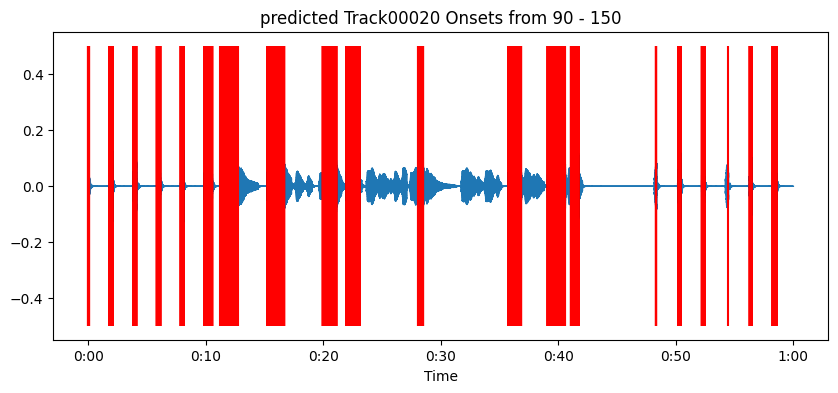

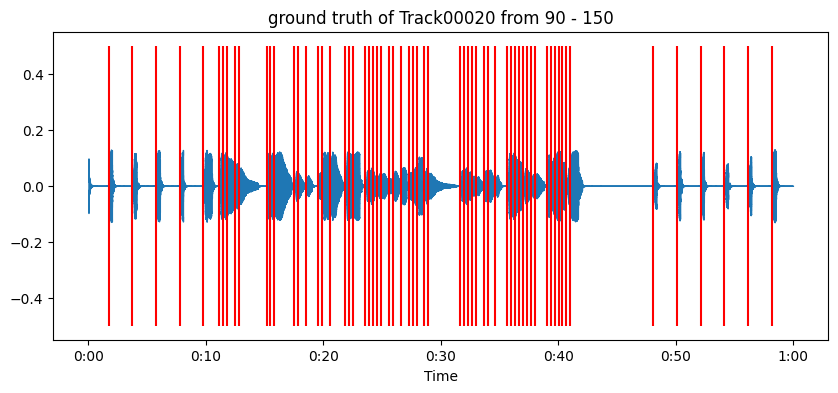

In [223]:
#--------PREDICTIONS-----
#print subset of music  
audio_start = 90 #in seconds
audio_end = 150

#splice y (audio) for the amplitudes during those tiems
intro = y[audio_start*sr:audio_end*sr]
#splice onsets for the onsets during that time 
sub_onsets = [x-audio_start for x in onset_times if x<audio_end and x>=audio_start]

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(intro, sr=sr)
plt.vlines(sub_onsets, -0.5, 0.5, color='r')
plt.title(f"predicted {track_name} Onsets from {audio_start} - {audio_end}")
print(sub_onsets)

#--------GROUND TRUTH-----

#splice y (audio) for the amplitudes during those tiems
intro_gt = y[audio_start*sr:audio_end*sr]
#splice onsets for the onsets during that time 
sub_onsets_gt = [x-audio_start for x in events_time_quantized if x<audio_end and x>=audio_start]

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(intro_gt, sr=sr)
plt.vlines(sub_onsets_gt, -0.5, 0.5, color='r')
plt.title(f"ground truth of {track_name} from {audio_start} - {audio_end}")

In [224]:
#ground truth with totlerance (instead of exact frame)
tolerance = 0.01

matches_babyslakh = []
for gt in sub_onsets_gt:

    # compute diff
    diff = np.array(sub_onsets) - gt

    if np.any(np.abs(diff) <= tolerance):
        matches_babyslakh.append(gt)

score = len(matches_babyslakh)
print(f"accuracy: {score}/{len(sub_onsets_gt)}")

accuracy: 14/64


### pipeline by pairs

In [206]:
threshold = 0.08
##------------Pipeline------------
folderpath = "../babyslakh_16k/Track00020/stems/S04.wav"
file = os.path.join(folderpath)
track_name = folderpath.split('/')[2]

start_time = time.time()

# Load audio
load_time = time.time()
print(f"loading audio: {load_time-start_time}")
y, sr = librosa.load(file, sr=None)
frequencies = log_frequencies(fmin=fmin, n_freqs=n_bins,freqs_per_octave=bins_per_octave)
alphas = alphas_heuristic( frequencies, sr)

# resonator filterbank
res_time = time.time()
print(f"resonate wrapper: {res_time-load_time}")
R = resonate_wrapper(y, sr, frequencies, alphas)
#print(R.shape) # R shape should be (time_frames, 128,)

#average pairs of vectors 
pairs = np.array([np.average(R[i:i+2, :], axis=0) for i in range(0, R.shape[0], 2)])

# similarity
cur_time = time.time()
print(f"taking euclidean diff: {cur_time-res_time}")
cos_diff = [euclidean(pairs[i],  pairs[i+1]) for i in range(len(pairs) - 1)]

#threshold for onsets
on_time = time.time()
print(f"detecting onsets: {on_time-cur_time}")
note_vectors = np.array(cos_diff)
onset_idx = np.where(note_vectors > threshold)[0] #ids of onsets in frames

#change from frames to time
fr_to_time_time = time.time()
print(f"detecting onsets: {fr_to_time_time-on_time}")
onset_times = onset_idx * 2*hop_length / sr #convert to time 
onset_samples = (onset_times * sr).astype(int)

#plot
plot_time = time.time()
print(f"plotting: {plot_time-fr_to_time_time}")
plt.figure(figsize=(10,4))
librosa.display.waveshow(y, sr=sr)
plt.vlines(onset_times, -1, 1, color='r')
plt.title(f"Predicted {track_name} Onsets with {threshold} threshold")
#print(note_vectors)
#print(distance_cosine)


plt.figure(figsize=(10,4))
plt.plot(note_vectors, linestyle='-')
plt.title("euclidean Distance Between Consecutive Notes")
plt.ylabel("Distance")
plt.xlabel("Note Index")
plt.grid(True)

#time
end_time = time.time()
print(f"time: {end_time - start_time}")


loading audio: 7.152557373046875e-06
resonate wrapper: 0.031853675842285156
[resonate_wrapper] resonate: 1.6590893268585205
n_freqs: 128
[resonate_wrapper] rsc np array: 19.021723747253418
[resonate_wrapper] reshape Rsc: 0.0072209835052490234
(5564059, 128) (5564059, 128)
[resonate_wrapper] compute complex values: 0.0011970996856689453


KeyboardInterrupt: 

In [187]:
#ground truth with totlerance (instead of exact frame)
tolerance = 0.01
events_time_quantized = quantize_time(events_time)

matches_babyslakh = []
for gt in events_time_quantized:

    # compute diff
    diff = onset_times - gt

    if np.any(np.abs(diff) <= tolerance):
        matches_babyslakh.append(gt)

score = len(matches_babyslakh)
print(f"accuracy: {score}/{len(events_time_quantized)}")

accuracy: 22/262


[np.float64(0.0010000000000047748), np.float64(0.001062500000003297), np.float64(0.001125000000001819), np.float64(0.007499999999993179), np.float64(0.0078125), np.float64(0.007874999999998522), np.float64(0.007937499999997044), np.float64(1.8371874999999989), np.float64(1.8372499999999974), np.float64(1.837312499999996), np.float64(1.837437499999993), np.float64(1.8409374999999955), np.float64(1.8441250000000053), np.float64(1.8441875000000039), np.float64(1.8442500000000024), np.float64(1.8476249999999936), np.float64(1.8476875000000064), np.float64(1.8477500000000049), np.float64(1.8478125000000034), np.float64(1.847875000000002), np.float64(1.8506249999999937), np.float64(1.8506875000000065), np.float64(1.850750000000005), np.float64(1.8508125000000035), np.float64(1.850875000000002), np.float64(1.8509375000000006), np.float64(1.8510624999999976), np.float64(1.8542499999999933), np.float64(1.854312500000006), np.float64(1.8545000000000016), np.float64(1.8545625000000001), np.float6

Text(0.5, 1.0, 'ground truth of Track00020 from 90 - 95')

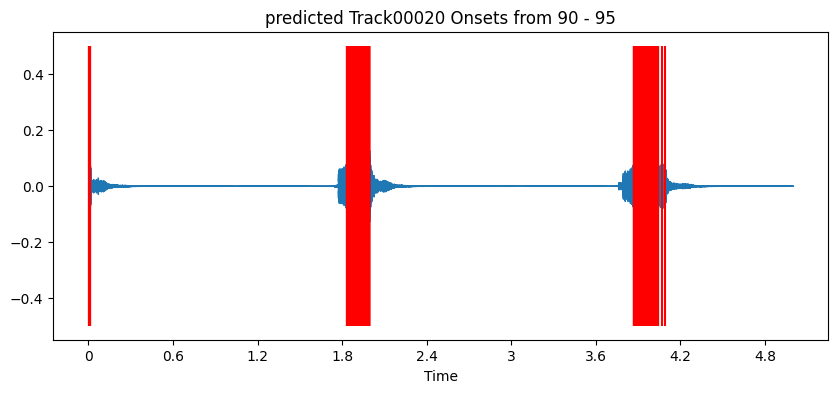

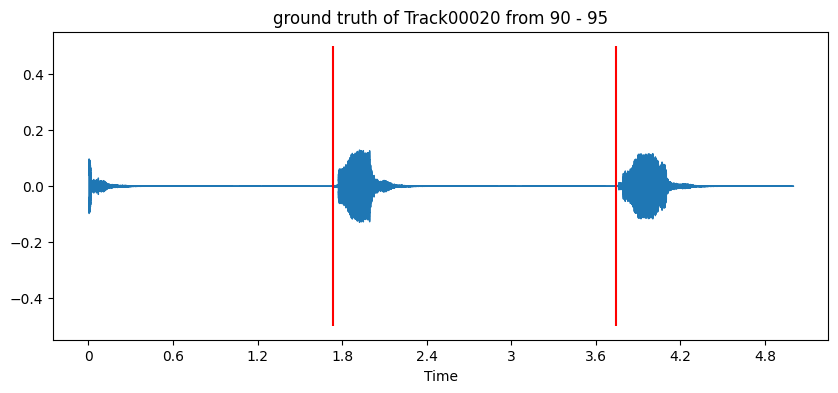

In [233]:
#--------PREDICTIONS-----
#print subset of music  
audio_start = 90 #in seconds
audio_end =95

#splice y (audio) for the amplitudes during those tiems
intro = y[audio_start*sr:audio_end*sr]
#splice onsets for the onsets during that time 
sub_onsets = [x-audio_start for x in onset_times if x<audio_end and x>=audio_start]

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(intro, sr=sr)
plt.vlines(sub_onsets, -0.5, 0.5, color='r')
plt.title(f"predicted {track_name} Onsets from {audio_start} - {audio_end}")
print(sub_onsets)

#--------GROUND TRUTH-----

#splice y (audio) for the amplitudes during those tiems
intro_gt = y[audio_start*sr:audio_end*sr]
#splice onsets for the onsets during that time 
sub_onsets_gt = [x-audio_start for x in events_time_quantized if x<audio_end and x>=audio_start]

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(intro_gt, sr=sr)
plt.vlines(sub_onsets_gt, -0.5, 0.5, color='r')
plt.title(f"ground truth of {track_name} from {audio_start} - {audio_end}")

In [189]:
#ground truth with totlerance (instead of exact frame)
tolerance = 0.01

matches_babyslakh = []
for gt in sub_onsets_gt:

    # compute diff
    diff = np.array(sub_onsets) - gt

    if np.any(np.abs(diff) <= tolerance):
        matches_babyslakh.append(gt)

score = len(matches_babyslakh)
print(f"accuracy: {score}/{len(sub_onsets_gt)}")

accuracy: 4/64


Text(0.5, 1.0, 'matches of Track00020 from 90 - 150')

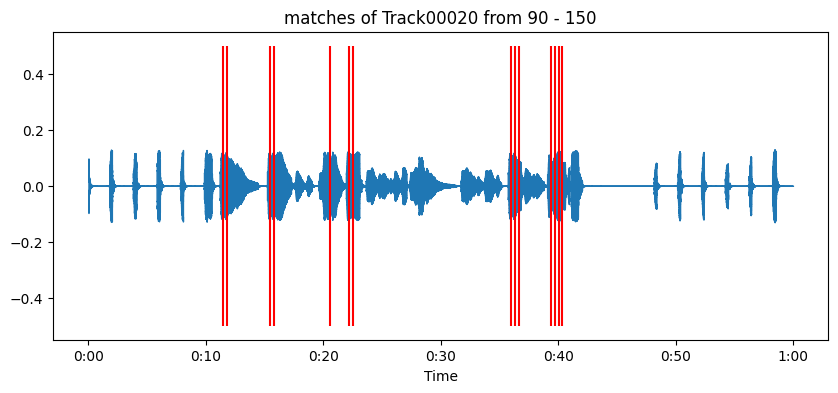

In [225]:
# only plotting matches 
intro_gt = y[audio_start*sr:audio_end*sr]
#splice onsets for the onsets during that time 
sub_onsets_gt = [x-audio_start for x in events_time_quantized if x<audio_end and x>=audio_start]

#plot
plt.figure(figsize=(10,4))
librosa.display.waveshow(intro_gt, sr=sr)
plt.vlines(matches_babyslakh, -0.5, 0.5, color='r')
plt.title(f"matches of {track_name} from {audio_start} - {audio_end}")

In [195]:
print([float(x) for x in sub_onsets])
print( sub_onsets_gt)

[1.850750000000005, 1.8611250000000013, 1.8687500000000057, 1.8753750000000053, 1.882125000000002, 1.8887500000000017, 1.8954999999999984, 1.902124999999998, 1.9023750000000064, 1.9067500000000024, 1.9074999999999989, 1.9081249999999983, 1.9083750000000066, 1.9124999999999943, 1.9154999999999944, 1.9157500000000027, 1.9198750000000047, 1.9201249999999987, 1.9214999999999947, 1.921750000000003, 1.9258750000000049, 1.9274999999999949, 1.929124999999999, 1.933250000000001, 1.9334999999999951, 1.9392500000000013, 1.9399999999999977, 1.9408750000000055, 1.9468750000000057, 1.9521249999999952, 1.9526249999999976, 1.952875000000006, 1.9542500000000018, 1.9595000000000056, 1.9599999999999937, 1.9655000000000058, 1.9722500000000025, 1.9723749999999995, 1.972875000000002, 1.9788750000000022, 1.985749999999996, 1.9892499999999984, 1.991624999999999, 1.9917499999999961, 3.877750000000006, 3.8957500000000067, 3.9026250000000005, 3.920375000000007, 3.9382499999999965, 3.9482500000000016, 3.955375000

In [235]:
R.shape

(5564059, 128)

In [ ]:
plt.plot(R[audio_start*sr:audio_end*sr])

: 

In [236]:
plt.figure(figsize=(12, 3))
librosa.display.specshow(
    R, 
    x_axis=None, # R is in time not samples 
    y_axis='linear',   # each row is one note, rahter than a chroma
    hop_length=hop_length,
    
)

plt.xlabel("Sample")
plt.ylabel("Note in hz")
plt.colorbar()
plt.show()

: 

: 